In [ ]:
!pip install neurokit2 MNE yasa 

In [2]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import mne
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

In [3]:
import warnings
import logging
warnings.filterwarnings('ignore')

logger = logging.getLogger()
logger.setLevel(logging.CRITICAL)
logging.getLogger("mne").setLevel(logging.WARNING) 

# Обработка биологических сигналов 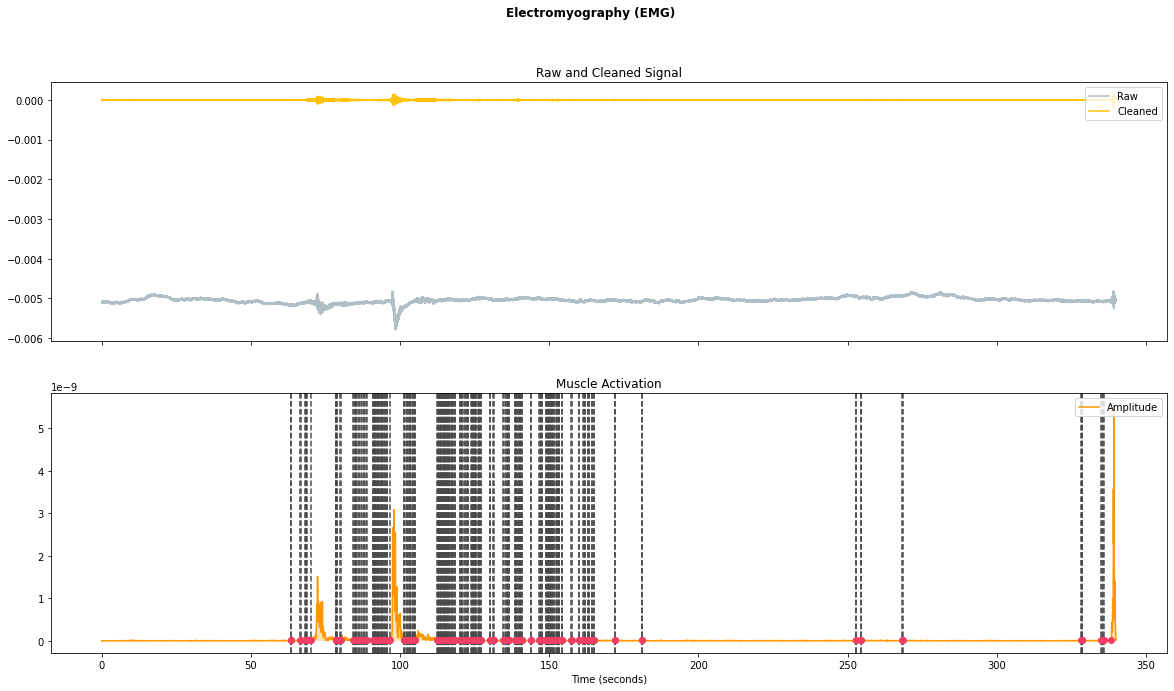 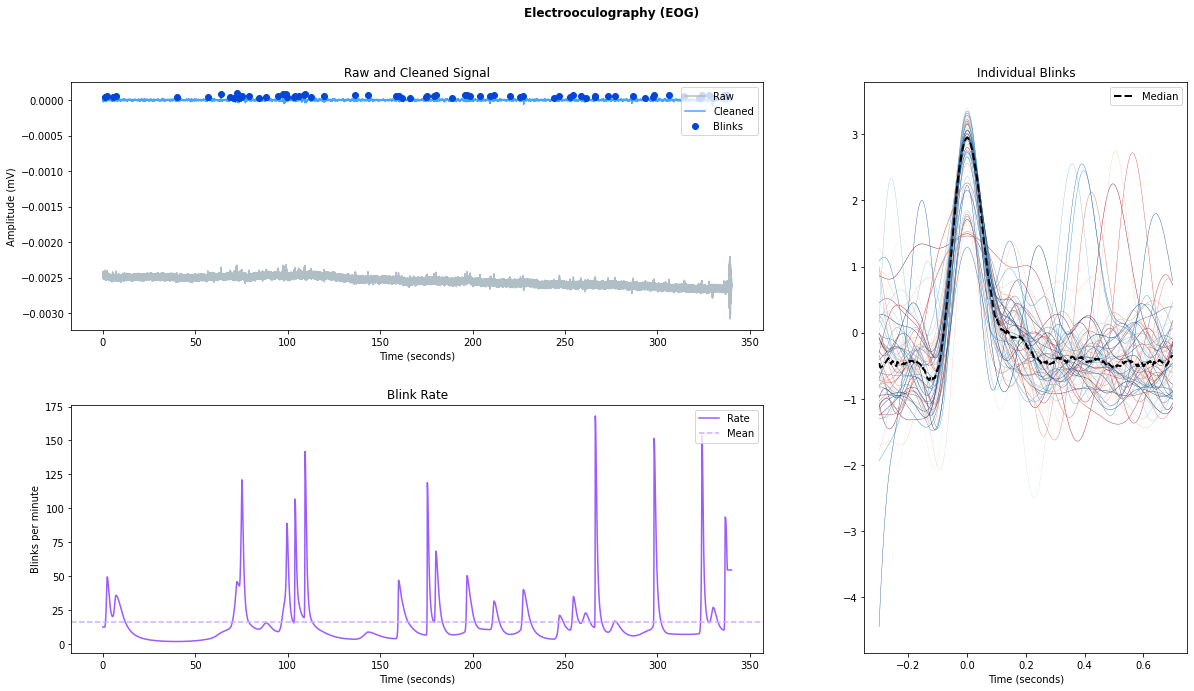   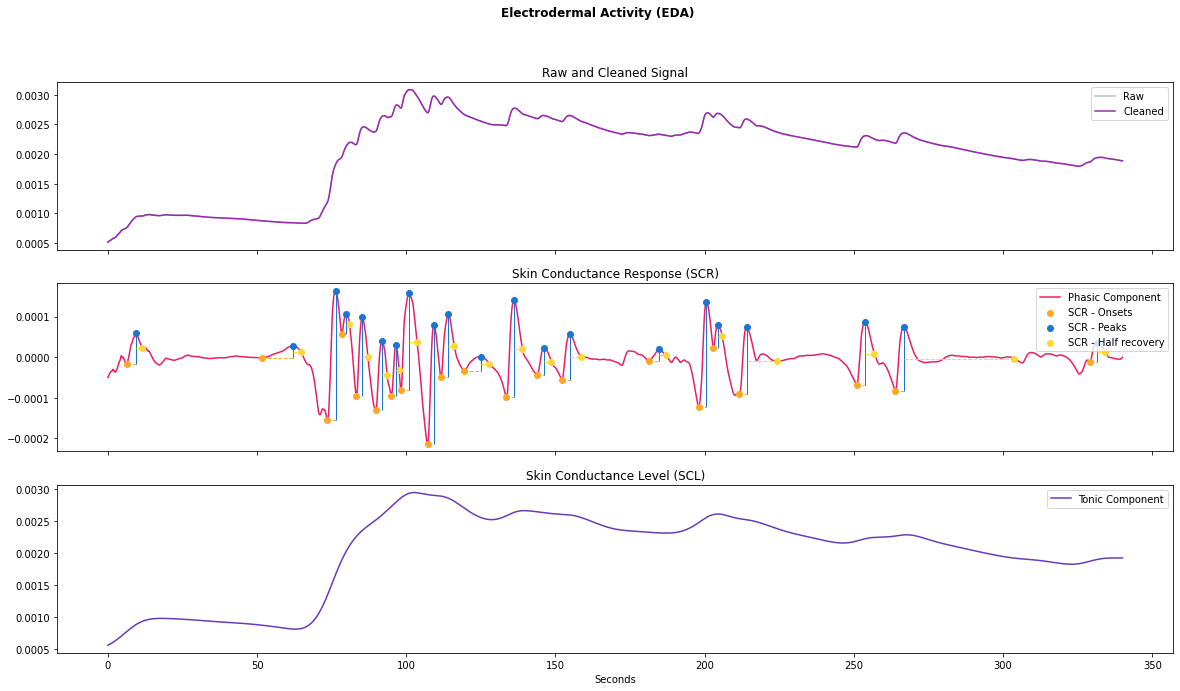 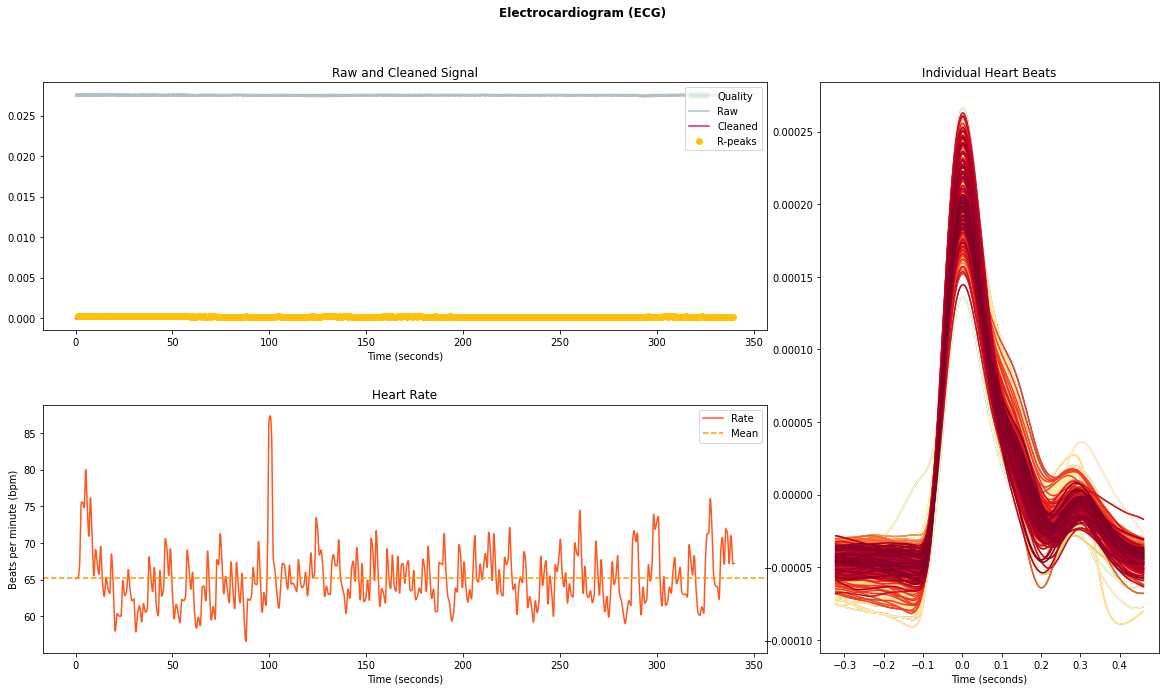 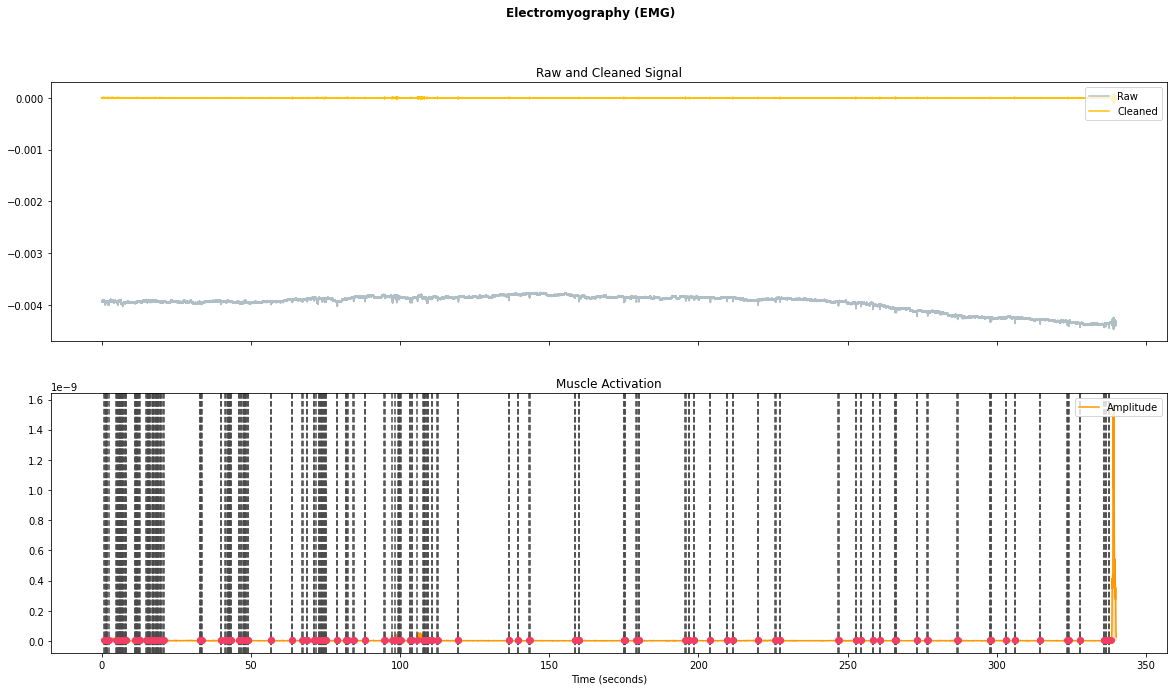

In [4]:
import matplotlib.collections
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neurokit2.misc import find_closest

In [5]:


def ed_plot(eda_signals, sampling_rate=None):
    """Visualize electrodermal activity (EDA) data.
    Parameters
    ----------
    eda_signals : DataFrame
        DataFrame obtained from `eda_process()`.
    sampling_rate : int
        The desired sampling rate (in Hz, i.e., samples/second). Defaults to None.
    Returns
    -------
    fig
        Figure representing a plot of the processed EDA signals.
    Examples
    --------
    >>> import neurokit2 as nk
    >>>
    >>> eda_signal = nk.eda_simulate(duration=30, scr_number=5, drift=0.1, noise=0, sampling_rate=250)
    >>> eda_signals, info = nk.eda_process(eda_signal, sampling_rate=250)
    >>> fig = nk.eda_plot(eda_signals)
    >>> fig #doctest: +SKIP
    See Also
    --------
    eda_process
    """
    # Determine peaks, onsets, and half recovery.
    peaks = np.where(eda_signals["SCR_Peaks"] == 1)[0]
    onsets = np.where(eda_signals["SCR_Onsets"] == 1)[0]
    half_recovery = np.where(eda_signals["SCR_Recovery"] == 1)[0]

    fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True)

    # Determine unit of x-axis.
    last_ax = fig.get_axes()[-1]
    if sampling_rate is not None:
        last_ax.set_xlabel("Seconds")
        x_axis = np.linspace(0, len(eda_signals) / sampling_rate, len(eda_signals))
    else:
        last_ax.set_xlabel("Samples")
        x_axis = np.arange(0, len(eda_signals))

    plt.subplots_adjust(hspace=0.2)

    # Plot cleaned and raw respiration as well as peaks and troughs.
    ax0.set_title("Raw and Cleaned Signal")
    fig.suptitle("Electrodermal Activity (EDA)", fontweight="bold")

    ax0.plot(x_axis, eda_signals["EDA_Raw"], color="#B0BEC5", label="Raw", zorder=1)
    ax0.plot(x_axis, eda_signals["EDA_Clean"], color="#9C27B0", label="Cleaned", linewidth=1.5, zorder=1)
    ax0.legend(loc="upper right")
    # Plot skin cnoductance response.
    ax1.set_title("Skin Conductance Response (SCR)")

    # Plot Phasic.
    ax1.plot(x_axis, eda_signals["EDA_Phasic"], color="#E91E63", label="Phasic Component", linewidth=1.5, zorder=1)

    # Mark segments.
    risetime_coord, amplitude_coord, halfr_coord = _eda_plot_dashedsegments(
        eda_signals, ax1, x_axis, onsets, peaks, half_recovery
    )
    risetime = matplotlib.collections.LineCollection(risetime_coord, colors="#FFA726", linewidths=1, linestyle="dashed")
    ax1.add_collection(risetime)

    amplitude = matplotlib.collections.LineCollection(
        amplitude_coord, colors="#1976D2", linewidths=1, linestyle="solid"
    )
    ax1.add_collection(amplitude)

    halfr = matplotlib.collections.LineCollection(halfr_coord, colors="#FDD835", linewidths=1, linestyle="dashed")
    ax1.add_collection(halfr)
    ax1.legend(loc="upper right")

    # Plot Tonic.
    ax2.set_title("Skin Conductance Level (SCL)")
    ax2.plot(x_axis, eda_signals["EDA_Tonic"], color="#673AB7", label="Tonic Component", linewidth=1.5)
    ax2.legend(loc="upper right")
    plt.show()
    return fig

def _eda_plot_dashedsegments(eda_signals, ax, x_axis, onsets, peaks, half_recovery):
    # Mark onsets, peaks, and half-recovery.
    scat_onset = ax.scatter(
        x_axis[onsets], eda_signals["EDA_Phasic"][onsets], color="#FFA726", label="SCR - Onsets", zorder=2
    )
    scat_peak = ax.scatter(
        x_axis[peaks], eda_signals["EDA_Phasic"][peaks], color="#1976D2", label="SCR - Peaks", zorder=2
    )
    scat_halfr = ax.scatter(
        x_axis[half_recovery],
        eda_signals["EDA_Phasic"][half_recovery],
        color="#FDD835",
        label="SCR - Half recovery",
        zorder=2,
    )
    end_onset = pd.Series(eda_signals["EDA_Phasic"][onsets].values, eda_signals["EDA_Phasic"][peaks].index[:len(eda_signals["EDA_Phasic"][onsets].values)] if len(eda_signals["EDA_Phasic"][onsets].values) > 0 else [])

    scat_endonset = ax.scatter(x_axis[end_onset.index], end_onset.values, alpha=0)
    # Rise time.

    risetime_start = scat_onset.get_offsets()
    risetime_end = scat_endonset.get_offsets()
    risetime_coord = [(risetime_start[i], risetime_end[i]) for i in range(0, len(onsets))]

    # SCR Amplitude.
    peak_top = scat_peak.get_offsets()
    amplitude_coord = [(peak_top[i], risetime_end[i]) for i in range(0, len(onsets))]

    # Half recovery.
    peak_x_values = peak_top.data[:, 0]
    recovery_x_values = x_axis[half_recovery]

    peak_list = []
    for i, index in enumerate(half_recovery):
        value = find_closest(recovery_x_values[i], peak_x_values, direction="smaller", strictly=False)
        peak_list.append(value)

    peak_index = []
    for i in np.array(peak_list):
        index = np.where(i == peak_x_values)[0][0]
        peak_index.append(index)

    halfr_index = list(range(0, len(half_recovery)))
    halfr_end = scat_halfr.get_offsets()
    halfr_start = [(peak_top[i, 0], halfr_end[x, 1]) for i, x in zip(peak_index, halfr_index)]
    halfr_coord = [(halfr_start[i], halfr_end[i]) for i in halfr_index]

    return risetime_coord, amplitude_coord, halfr_coord

In [6]:
def _emg_plot_activity(emg_signals, onsets, offsets):
    activity_signal = pd.Series(np.full(len(emg_signals), np.nan))
    activity_signal[onsets] = emg_signals["EMG_Amplitude"][onsets].values
    activity_signal[offsets] = emg_signals["EMG_Amplitude"][offsets].values
    activity_signal = activity_signal.fillna(method="backfill")
    if np.any(activity_signal.isna()):
        #print(np.min(np.where(activity_signal.isna())) - 1)
        #print(np.where(activity_signal.isna()))
        #print(activity_signal.isna())
        index = np.min(np.where(activity_signal.isna())) - 1
        if index < 0:
            index = 0
    value_to_fill = activity_signal[index]
    activity_signal = activity_signal.fillna(value_to_fill)

    return activity_signal

In [7]:
def em_plot(emg_signals, sampling_rate=None):
    """Visualize electromyography (EMG) data.
    Parameters
    ----------
    emg_signals : DataFrame
        DataFrame obtained from `emg_process()`.
    sampling_rate : int
        The sampling frequency of the EMG (in Hz, i.e., samples/second). Needs to be supplied if the
        data should be plotted over time in seconds. Otherwise the data is plotted over samples.
        Defaults to None.
    Returns
    -------
    fig
        Figure representing a plot of the processed emg signals.
    Examples
    --------
    >>> import neurokit2 as nk
    >>>
    >>> emg = nk.emg_simulate(duration=10, sampling_rate=1000, burst_number=3)
    >>> emg_signals, _ = nk.emg_process(emg, sampling_rate=1000)
    >>> fig = nk.emg_plot(emg_signals)
    >>> fig #doctest: +SKIP
    See Also
    --------
    ecg_process
    """
    # Mark onsets, offsets, activity
    onsets = np.where(emg_signals["EMG_Onsets"] == 1)[0]
    offsets = np.where(emg_signals["EMG_Offsets"] == 1)[0]
    # Sanity-check input.
    if not isinstance(emg_signals, pd.DataFrame):
        raise ValueError(
            "NeuroKit error: The `emg_signals` argument must"
            " be the DataFrame returned by `emg_process()`."
        )
    # Determine what to display on the x-axis, mark activity.
    if sampling_rate is not None:
        x_axis = np.linspace(0, emg_signals.shape[0] / sampling_rate, emg_signals.shape[0])
    else:
        x_axis = np.arange(0, emg_signals.shape[0])
    # Prepare figure.
    fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, sharex=True)
    if sampling_rate is not None:
        ax1.set_xlabel("Time (seconds)")
    elif sampling_rate is None:
        ax1.set_xlabel("Samples")
    
    fig.suptitle("Electromyography (EMG)", fontweight="bold")
    plt.subplots_adjust(hspace=0.2)

    # Plot cleaned and raw EMG.
    ax0.set_title("Raw and Cleaned Signal")
    ax0.plot(x_axis, emg_signals["EMG_Raw"], color="#B0BEC5", label="Raw", zorder=1)
    ax0.plot(x_axis, emg_signals["EMG_Clean"], color="#FFC107", label="Cleaned", zorder=1, linewidth=1.5)
    ax0.legend(loc="upper right")
    # Plot Amplitude.
    ax1.set_title("Muscle Activation")
    ax1.plot(x_axis, emg_signals["EMG_Amplitude"], color="#FF9800", label="Amplitude", linewidth=1.5)

    # Shade activity regions.
    activity_signal = _emg_plot_activity(emg_signals, onsets, offsets)
    ax1.fill_between(
        x_axis,
        emg_signals["EMG_Amplitude"],
        activity_signal,
        where=emg_signals["EMG_Amplitude"] > activity_signal,
        color="#f7c568",
        alpha=0.5,
        label=None,
    )

    # Mark onsets and offsets.
    ax1.scatter(x_axis[onsets], emg_signals["EMG_Amplitude"][onsets], color="#f03e65", label=None, zorder=3)
    ax1.scatter(x_axis[offsets], emg_signals["EMG_Amplitude"][offsets], color="#f03e65", label=None, zorder=3)

    if sampling_rate is not None:
        onsets = onsets / sampling_rate
        offsets = offsets / sampling_rate
    for i, j in zip(list(onsets), list(offsets)):
        ax1.axvline(i, color="#4a4a4a", linestyle="--", label=None, zorder=2)
        ax1.axvline(j, color="#4a4a4a", linestyle="--", label=None, zorder=2)
    ax1.legend(loc="upper right")
    plt.show()
    return fig

In [ ]:
def make_image(sensors, Subject, film, sfreq, is_relax):
    if not os.path.exists('Bio_images/S' + Subject + '/' + film + '/'):
        os.makedirs('Bio_images/S' + Subject + '/' + film + '/')
    data = pd.DataFrame({"EDA": sensors[0],
                      "EOG": sensors[1],
                      "ECG": sensors[2],
                      "Zygom": sensors[3],
                      "Corr" : sensors[4], 
                     })
    if not os.path.isfile('Bio_images/S' + Subject + '/' + film + '/' + ('eda_relax.png' if is_relax else 'eda_watch.png')):
        signals, info = nk.eda_process(data['EDA'], sampling_rate=sfreq)

        # Visualise the processing
        plot = ed_plot(signals, sampling_rate=sfreq)
        plot.set_size_inches(20, 10.5)
        plot.savefig('Bio_images/S' + Subject + '/' + film + '/' + ('eda_relax.png' if is_relax else 'eda_watch.png'), bbox_inches='tight')

    if not os.path.isfile('Bio_images/S' + Subject + '/' + film + '/' + ('ecg_relax.png' if is_relax else 'ecg_watch.png')):

        signals, info = nk.ecg_process(data['ECG'], sampling_rate=sfreq)

        # Visualise the processing
        plot = nk.ecg_plot(signals, sampling_rate=sfreq)
        plot.set_size_inches(20, 10.5)
        plot.savefig('Bio_images/S' + Subject + '/' + film + '/' + ('ecg_relax.png' if is_relax else 'ecg_watch.png'), bbox_inches='tight')

    if not os.path.isfile('Bio_images/S' + Subject + '/' + film + '/' + ('zygom_relax.png' if is_relax else 'zygom_watch.png')):

        signals, info = nk.emg_process(data['Zygom'], sampling_rate=sfreq)
        # Visualise the processing
        plot = em_plot(signals, sampling_rate=sfreq)
        plot.set_size_inches(20, 10.5)
        plot.savefig('Bio_images/S' + Subject + '/' + film + '/' + ('zygom_relax.png' if is_relax else 'zygom_watch.png'), bbox_inches='tight')
 
    if not os.path.isfile('Bio_images/S' + Subject + '/' + film + '/' + ('corr_relax.png' if is_relax else 'corr_watch.png')):

        signals, info = nk.emg_process(data['Corr'], sampling_rate=sfreq)
        # Visualise the processing
        plot = em_plot(signals, sampling_rate=sfreq)
        plot.set_size_inches(20, 10.5)
        plot.savefig('Bio_images/S' + Subject + '/' + film + '/' + ('corr_relax.png' if is_relax else 'corr_watch.png'), bbox_inches='tight')

    if not os.path.isfile('Bio_images/S' + Subject + '/' + film + '/' + ('eog_relax.png' if is_relax else 'eog_watch.png')):

        signals, info = nk.eog_process(data['EOG'], sampling_rate=sfreq)

        # Plot
        plot = nk.eog_plot(signals, info, sampling_rate=sfreq)
        plot.set_size_inches(20, 10.5) 
  
        plot.savefig('Bio_images/S' + Subject + '/' + film + '/' + ('eog_relax.png' if is_relax else 'eog_watch.png'), bbox_inches='tight')



In [ ]:
for i in tqdm_notebook(range(n_subj)):
    Subject = str(i + 1)
    for j in tqdm_notebook(range(n_film)):
        film = str(j + 1)
        watch = mne.io.read_raw('Cuts_not_filtered/' + Subject + '/' + 'watch_' + film + '.fif')
        relax = mne.io.read_raw('Cuts_not_filtered/' + Subject + '/' + 'relax_before_' + film + '.fif')
        eda_watch = np.array(watch['EDA'][0][0])
        if int(Subject) < 6:
            eog_watch = np.array(watch['F3'][0][0])
        else:
            eog_watch = np.array(watch['VEOG'][0][0])
        ecg_watch = np.array(watch['Pulse'][0][0])
        zygom_watch = np.array(watch['Zygom'][0][0])
        corr_watch = np.array(watch['Corr'][0][0])
        eda_relax = np.array(relax['EDA'][0][0])
        if int(Subject) < 6:
            eog_relax = np.array(relax['F3'][0][0])
        else:
            eog_relax = np.array(relax['VEOG'][0][0])
        ecg_relax = np.array(relax['Pulse'][0][0])
        zygom_relax = np.array(relax['Zygom'][0][0])
        corr_relax = np.array(relax['Corr'][0][0])

        make_image([eda_watch, eog_watch, ecg_watch, zygom_watch, corr_watch], Subject, film, watch.info['sfreq'], False)
        try:
            make_image([eda_relax, eog_relax, ecg_relax, zygom_relax, corr_relax], Subject, film, relax.info['sfreq'], True)
        except Exception as e:
            continue


Пики ЭКГ 

In [ ]:
for i in tqdm(n_subj):
    Subject = str(i + 1)
    for j in tqdm(n_films):
        film = str(j + 1)
        if not os.path.isfile('Peaks_ecg/S' + Subject + '/F' + film + '/table_watch.xlsx') or not os.path.isfile('Peaks_ecg/S' + Subject + '/F' + film + '/peaks_watch.xlsx'):
            watch = mne.io.read_raw('Cuts_filtered/' + Subject +'/00' + Subject + '_filtered_watch_' + film + '_.fif')
            df, info = nk.ecg_process(watch["Pulse"][0][0], sampling_rate=watch.info['sfreq'])
        if not os.path.exists('Peaks_ecg/S' + Subject + '/F' + film):
            os.makedirs('/content/gdrive/MyDrive/Research/Project2022/Peaks_ecg/S' + Subject + '/F' + film)
        if not os.path.isfile('Peaks_ecg/S' + Subject + '/F' + film + '/peaks_watch.xlsx'):
            pd.DataFrame(info).drop(['sampling_rate'], axis=1).to_excel('Peaks_ecg/S' + Subject + '/F' + film + '/peaks_watch.xlsx')
        if not os.path.isfile('Peaks_ecg/S' + Subject + '/F' + film + '/table_watch.xlsx'):
            df.to_excel('Peaks_ecg/S' + Subject + '/F' + film + '/table_watch.xlsx')